In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, ConfusionMatrixDisplay, classification_report


In [2]:
RANDOM_STATE = 0
PATH = "dataset.csv"
POPULAR_THRESHOLD = 70

feat_cols = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", 
    "valence", "tempo", "duration_ms", "key", "mode", "time_signature", "explicit"]

In [3]:
df = pd.read_csv(PATH)

popularity_scores = df["popularity"]
is_popular = popularity_scores >= POPULAR_THRESHOLD
df["label_popular"] = is_popular

feat_table = df[feat_cols]

feat_medians = feat_table.median()
new_feat = feat_table.fillna(feat_medians)

X = new_feat.to_numpy()
y = df["label_popular"].to_numpy()

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_size = X_train_scaled.shape[0]
test_size = X_test_scaled.shape[0]
print("Train size: " + str(train_size))
print("Test size: " + str(test_size))


Train size: 91200
Test size: 22800


In [5]:
linear_discriminant_analysis_model = LinearDiscriminantAnalysis(priors=np.array([0.5, 0.5]))
linear_discriminant_analysis_model.fit(X_train_scaled, y_train)

print("Priors: " + str(linear_discriminant_analysis_model.priors_))


Priors: [0.5 0.5]


In [6]:
threshold = 0.5
probability_matrix = linear_discriminant_analysis_model.predict_proba(X_test_scaled)
test_popular_proba = probability_matrix[:, 1]
y_test_pred = test_popular_proba >= threshold

In [7]:
accuracy = accuracy_score(y_test, y_test_pred)
error = 1.0 - accuracy
precision = precision_score(y_test, y_test_pred, pos_label=True, zero_division=0)
recall = recall_score(y_test, y_test_pred, pos_label=True, zero_division=0)
f1_metric = f1_score(y_test, y_test_pred, pos_label=True, zero_division=0)
roc_auc = roc_auc_score(y_test, test_popular_proba)
confusion = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix:")
print(confusion)
print("")
print("Threshold: " + str(threshold))
print("Accuracy: " + str(accuracy))
print("Error: " + str(error))
print("Precision: " + str(precision))
print("Recall: " + str(recall))
print("F1 score: " + str(f1_metric))
print("ROC-AUC: " + str(roc_auc))

print("")
print("Classification report:")
print(classification_report(y_test, y_test_pred, target_names=["not_popular", "popular"], zero_division=0))

roc_false_positive_rate, roc_true_positive_rate, roc_threshold_values = roc_curve(y_test, test_popular_proba)


Confusion matrix:
[[13179  8527]
 [  350   744]]

Threshold: 0.5
Accuracy: 0.6106578947368421
Error: 0.38934210526315793
Precision: 0.0802502426922662
Recall: 0.680073126142596
F1 score: 0.14356005788712012
ROC-AUC: 0.6961272892136244

Classification report:
              precision    recall  f1-score   support

 not_popular       0.97      0.61      0.75     21706
     popular       0.08      0.68      0.14      1094

    accuracy                           0.61     22800
   macro avg       0.53      0.64      0.45     22800
weighted avg       0.93      0.61      0.72     22800



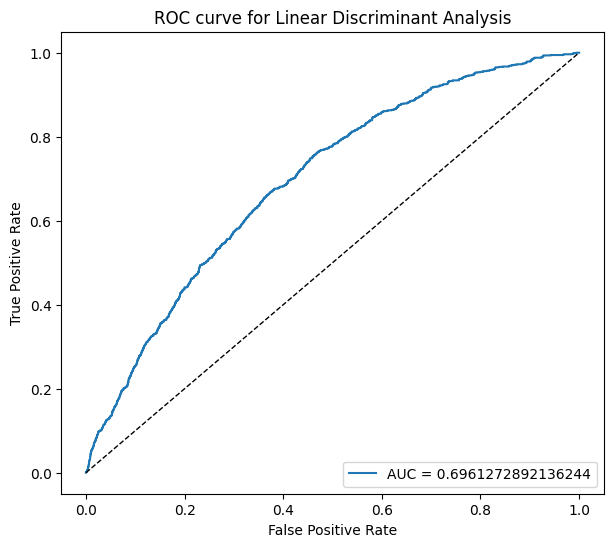

In [8]:
plt.figure(figsize=(7, 6))
auc_label = "AUC = " + str(roc_auc)
plt.plot(roc_false_positive_rate, roc_true_positive_rate, label=auc_label)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve for Linear Discriminant Analysis")
plt.legend(loc="lower right")
plt.show()


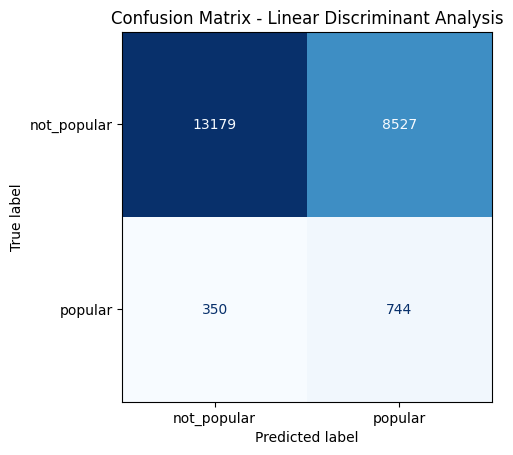

In [9]:
confusion_matrix_display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["not_popular", "popular"])
confusion_matrix_display.plot(values_format="d", cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Linear Discriminant Analysis")
plt.show()

In [10]:
model_coefficients = linear_discriminant_analysis_model.coef_[0]
coefficients_df = pd.DataFrame({"feature": feat_cols, "coef": model_coefficients})
coefficients_df["abs_coef"] = np.abs(coefficients_df["coef"])

pos_rows = []
neg_rows = []
pos_count = 0
neg_count = 0
for i in range(len(coefficients_df)):
    row = coefficients_df.iloc[i]
    coef_value = row["coef"]
    if coef_value > 0:
        pos_rows.append(row)
        pos_count = pos_count + 1
    if coef_value < 0:
        neg_rows.append(row)
        neg_count = neg_count + 1

pos_df = pd.DataFrame(pos_rows).sort_values("abs_coef", ascending=False)
neg_df = pd.DataFrame(neg_rows).sort_values("abs_coef", ascending=False)

print("")
print("There are " + str(pos_count) + " features with positive coefficients (they increase predicted probability of popular).")
print("There are " + str(neg_count) + " features with negative coefficients (they decrease predicted probability of popular).")
print("")
print("Top five features by absolute positive coefficient (strength toward popular):")
print(pos_df.head(5)[["feature", "coef"]].to_string(index=False))

print("")
print("Top five features by absolute negative coefficient (strength away from popular):")
print(neg_df.head(5)[["feature", "coef"]].to_string(index=False))

print("")
print("All coefficients, sorted from largest to smallest:")
coefficients_sorted = coefficients_df.sort_values("coef", ascending=False)
coefficients_table = coefficients_sorted[["feature", "coef"]]
print(coefficients_table)



There are 4 features with positive coefficients (they increase predicted probability of popular).
There are 10 features with negative coefficients (they decrease predicted probability of popular).

Top five features by absolute positive coefficient (strength toward popular):
       feature     coef
      explicit 0.257408
      loudness 0.207595
  danceability 0.153934
time_signature 0.001821

Top five features by absolute negative coefficient (strength away from popular):
         feature      coef
instrumentalness -0.338762
    acousticness -0.333335
          energy -0.271546
        liveness -0.194079
     speechiness -0.160870

All coefficients, sorted from largest to smallest:
             feature      coef
13          explicit  0.257408
2           loudness  0.207595
0       danceability  0.153934
12    time_signature  0.001821
10               key -0.010473
9        duration_ms -0.057263
11              mode -0.058089
7            valence -0.071550
8              tempo -0.1102